In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider

In [2]:
class VariationalAutoencoder(nn.Module):
    def __init__(self, latentDim=32):
        super().__init__()
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),  # 28x28 image
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14x14 image
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), # 7x7 image
            nn.BatchNorm2d(64),
            nn.ReLU(),
    
            nn.Flatten() # output 64x7x7 tensor
        )
        
        #Bottleneck Layer
        self.latentMean = nn.Linear(64 * 7 * 7, latentDim)
        self.latentVariance = nn.Linear(64 * 7 * 7, latentDim)
        
        # Decoder
        self.latentProjection = nn.Linear(latentDim, 64 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), #upscale: 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), #upscale: 14x14 -> 28x28
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid() # values to [0, 1] matching normalized data
        )

    def encode(self, x):
        latentFeatures = self.encoder(x)
        mu = self.latentMean(latentFeatures)
        logVar = self.latentVariance(latentFeatures)
        return mu, logVar

    def reparameterize(self, mu, logVar):
        std = torch.exp(0.5 * logVar) 
        epsilon = torch.randn_like(std)
        return mu + epsilon * std

    def decode(self, z):
        xFlattened = self.latentProjection(z)
        xReshaped = xFlattened.view(-1, 64, 7, 7)
        return self.decoder(xReshaped)

    def forward(self, x):
        mu, logVar = self.encode(x)
        z = self.reparameterize(mu, logVar)
        xHat = self.decode(z)
        return xHat, mu, logVar

In [3]:
def computeLoss(xHat, x, mu, logVar, betaWeight=1.0):
    # Gaussian Likelihood with an assumed constant variance reduces directly to Summed Squared Error
    reconstructionLoss = nn.functional.mse_loss(xHat, x, reduction='sum')
    
    # Closed-form KL Divergence for an analytical Gaussian prior N(0, I)
    KLdivergence = -0.5 * torch.sum(1 + logVar - mu.pow(2) - logVar.exp())
    
    loss = reconstructionLoss + (betaWeight * KLdivergence)
    return loss, reconstructionLoss, KLdivergence

In [4]:
def trainModel():
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"Target execution hardware configured to: {device}")
    
    # Configuration Hyperparameters
    latentDim = 32
    batchSize = 256
    learningRate = 1e-3
    epochs = 30
    
    # EMNIST Pipeline Setup
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    
    # "balanced" split contains equal distribution of digits and uppercase/lowercase letters
    trainDataset = datasets.EMNIST(
        root="./data", 
        split="balanced", 
        train=True, 
        download=True, 
        transform=transform
    )
    trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
    
    # Explicit Instantiations
    model = VariationalAutoencoder(latentDim=latentDim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learningRate)
    
    # Explicit Manual Training Optimization Loop
    for epoch in range(epochs):

        if epoch < 10:
            betaWeight = epoch / 10.0
        else:
            betaWeight = 1.0

        model.train()
        totalLoss = 0.0
        totalRecon = 0.0
        totalKl = 0.0
        
        for batchIdx, (data, _) in enumerate(trainLoader):
            data = data.to(device)
            
            # Clear historical tracking tensors manually
            optimizer.zero_grad()
            
            # Direct forward execution pass
            reconData, mu, logVar = model(data)
            
            # Compute individual mathematical elements
            loss, reconstructionLoss, KLdivergence = computeLoss(reconData, data, mu, logVar, betaWeight)
            
            # Direct backward propagation pass
            loss.backward()
            
            # Execute parameter modifications
            optimizer.step()
            
            totalLoss += loss.item()
            totalRecon += reconstructionLoss.item()
            totalKl += KLdivergence.item()
            
        averageLoss = totalLoss / len(trainLoader.dataset)
        averageRecon = totalRecon / len(trainLoader.dataset)
        averageKl = totalKl / len(trainLoader.dataset)
        
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {averageLoss:.4f} | Recon (MSE): {averageRecon:.4f} | KL: {averageKl:.4f}")
        
    return model, averageLoss, averageRecon, averageKl

In [5]:
trainedModel, averageLoss, averageRecon, averageKl = trainModel()

Target execution hardware configured to: mps
Epoch 01/30 | Loss: 19.5330 | Recon (MSE): 19.5330 | KL: 479.4478
Epoch 02/30 | Loss: 15.1868 | Recon (MSE): 8.7693 | KL: 64.1756
Epoch 03/30 | Loss: 18.0950 | Recon (MSE): 9.1452 | KL: 44.7488
Epoch 04/30 | Loss: 21.4152 | Recon (MSE): 10.3463 | KL: 36.8964
Epoch 05/30 | Loss: 24.3273 | Recon (MSE): 11.6362 | KL: 31.7277
Epoch 06/30 | Loss: 26.8728 | Recon (MSE): 12.9296 | KL: 27.8864
Epoch 07/30 | Loss: 29.1537 | Recon (MSE): 14.1917 | KL: 24.9366
Epoch 08/30 | Loss: 31.1980 | Recon (MSE): 15.4327 | KL: 22.5218
Epoch 09/30 | Loss: 33.1048 | Recon (MSE): 16.6336 | KL: 20.5890
Epoch 10/30 | Loss: 34.8297 | Recon (MSE): 17.8210 | KL: 18.8986
Epoch 11/30 | Loss: 36.4464 | Recon (MSE): 18.9579 | KL: 17.4886
Epoch 12/30 | Loss: 36.3046 | Recon (MSE): 18.9716 | KL: 17.3330
Epoch 13/30 | Loss: 36.1037 | Recon (MSE): 18.8968 | KL: 17.2069
Epoch 14/30 | Loss: 35.9510 | Recon (MSE): 18.8294 | KL: 17.1216
Epoch 15/30 | Loss: 35.8594 | Recon (MSE): 18.

In [6]:
torch.save(trainedModel.state_dict(), "EMNIST_VAE_Trained.pt")

Loading the trained model

In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu") #Maybe change to GPU of Colab


In [8]:
loadedModel = VariationalAutoencoder(latentDim=32)
weights = torch.load("EMNIST_VAE_Trained.pt", map_location=device)
loadedModel.load_state_dict(weights)
loadedModel.to(device)
loadedModel.eval()

VariationalAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU()
    (9): Flatten(start_dim=1, end_dim=-1)
  )
  (latentMean): Linear(in_features=3136, out_features=32, bias=True)
  (latentVariance): Linear(in_features=3136, out_features=32, bias=True)
  (latentProjection): Linear(in_features=32, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_

Tests

In [9]:
def evaluateReconstructions(model, device, numImages=8):
    """Plots original images side-by-side with their VAE reconstructions."""
    model.eval()
    
    # Load Test Data
    transform = transforms.Compose([transforms.ToTensor()])
    testDataset = datasets.EMNIST(
            root="./data", 
            split="balanced", 
            train=False, 
            download=True, 
            transform=transform
        )
    testLoader = DataLoader(testDataset, batch_size=numImages, shuffle=True)
    
    # Grab one batch
    realImages, _ = next(iter(testLoader))
    realImages = realImages.to(device)
    
    with torch.no_grad():
        reconImages, _, _ = model(realImages)
        
    # Move to CPU for matplotlib
    realImages = realImages.cpu().numpy()
    reconImages = reconImages.cpu().numpy()
    
    fig, axes = plt.subplots(2, numImages, figsize=(numImages * 2, 4))
    
    for i in range(numImages):
        # Top Row: Real Images
        axes[0, i].imshow(realImages[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title("Original")
            
        # Bottom Row: Reconstructions
        axes[1, i].imshow(reconImages[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title("Reconstructed")
            
    plt.tight_layout()
    plt.show()

In [10]:
def evaluateInterpolation(model, device, steps=10):
    """Generates a static grid showing the transition between two characters."""
    model.eval()
    
    transform = transforms.Compose([transforms.ToTensor()])
    testDataset = datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
    testLoader = DataLoader(testDataset, batch_size=2, shuffle=True)
    
    images, _ = next(iter(testLoader))
    images = images.to(device)
    
    with torch.no_grad():
        # Use the mean (mu) for interpolation to avoid sampling noise
        mu, _ = model.encode(images)
        latentStart = mu[0]
        latentEnd = mu[1]
        
        # Create linear steps between the two latent vectors
        alphas = torch.linspace(0, 1, steps).to(device)
        latentSteps = torch.stack([(1 - a) * latentStart + a * latentEnd for a in alphas])
        
        # Decode the intermediate steps
        decodedImages = model.decode(latentSteps).cpu().numpy()
        
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.5, 2))
    for i in range(steps):
        axes[i].imshow(decodedImages[i].squeeze(), cmap='gray')
        axes[i].axis('off')
        if i == 0:
            axes[i].set_title("Start")
        elif i == steps - 1:
            axes[i].set_title("End")
            
    plt.tight_layout()
    plt.show()

In [11]:
# def interactiveLatentExplorer(model, device):
#     """Creates a UI slider to smoothly traverse the latent space between two random images."""
#     model.eval()
    
#     transform = transforms.Compose([transforms.ToTensor()])
#     testDataset = datasets.EMNIST(
#             root="./data", 
#             split="balanced", 
#             train=False, 
#             download=True, 
#             transform=transform
#         )
#     testLoader = DataLoader(testDataset, batch_size=2, shuffle=True)
    
#     images, _ = next(iter(testLoader))
#     images = images.to(device)
    
#     with torch.no_grad():
#         mu, _ = model.encode(images)
#         latentStart = mu[0]
#         latentEnd = mu[1]

#     # This function is called every time you move the slider
#     def renderInterpolationStep(t):
#         with torch.no_grad():
#             latentCurrent = (1 - t) * latentStart + t * latentEnd
#             # Add batch dimension for the decoder
#             latentCurrent = latentCurrent.unsqueeze(0) 
#             decodedImage = model.decode(latentCurrent).squeeze().cpu().numpy()
            
#         plt.figure(figsize=(3, 3))
#         plt.imshow(decodedImage, cmap='gray')
#         plt.axis('off')
#         plt.title(f"Latent Morph: {t*100:.0f}%")
#         plt.show()

#     # Create the interactive slider widget
#     print("Slide to navigate the Latent Space:")
#     interact(renderInterpolationStep, t=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.0))

--- Reconstruction Test ---


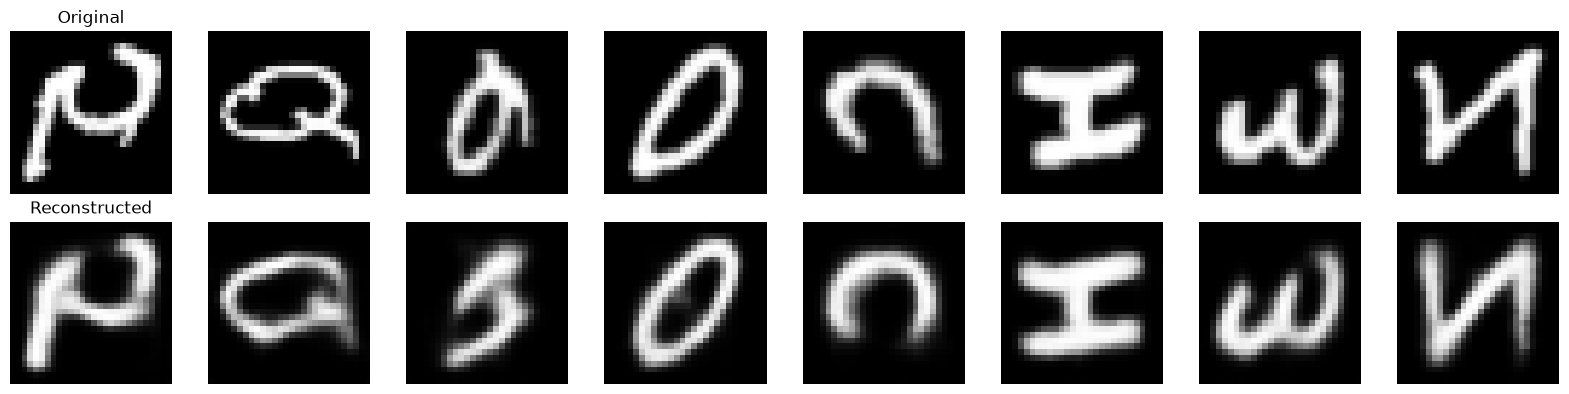

In [12]:
print("--- Reconstruction Test ---")
evaluateReconstructions(trainedModel, device)


--- Static Interpolation ---


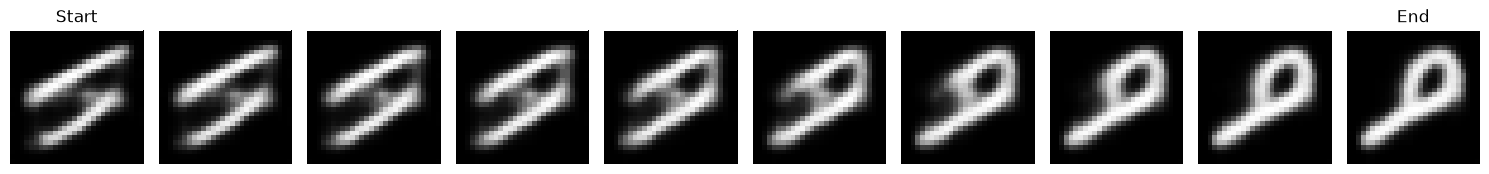

In [13]:
print("\n--- Static Interpolation ---")
evaluateInterpolation(trainedModel, device)

In [ ]:
# print("\n--- Interactive Latent Space Explorer ---")
# interactiveLatentExplorer(trainedModel, device)